# "We checked the variances first"

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/assumption-pretest-cost/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/assumption-pretest-cost/demo.ipynb)

Run Levene on the two groups. If it rejects, use Welch's t. If it does not, use Student's pooled
t. This is taught as due diligence, and it is the most defensible-sounding thing in the room.

It is also **one procedure, not two**, and the only honest way to describe it is to measure what
*it* does - not what its two branches do separately. Two things make it worse than it looks:

**The pretest reads the same numbers the t-test does.** Levene's decision is a function of the
sample variances. Student's pooled standard error is a function of the same sample variances. So
"the pretest passed" is not a random subset of your samples - it is the subset whose variance
ratio *happened to look small*, which is exactly the subset where the pooled estimate flatters
itself. The selection is correlated with the statistic it selects.

**The pretest has a power curve.** At a moderate variance gap it misses most of the time - and a
moderate gap is precisely where Student's has already started to fail.

Nothing below is an argument. Both groups always have the **same mean**, so the null is exactly
true and every rejection counted is a false positive by construction.

**What is here**

1. The engine, from the formulas, so this notebook runs standalone
2. Calibration: the one cell whose answer is known exactly
3. The three procedures on identical samples
4. The mechanism - what the gate does to Student's, conditioned on its own verdict
5. The danger zone, which is a moderate variance gap and not a large one
6. Whether a more generous pretest alpha fixes it

## 1. The engine

Two t-tests and four pretests, written out rather than imported. Every group is standardised with
its **population** moments - not the sample's - so the null under test really is true rather than
true on average.

In [1]:
from __future__ import annotations

import math
from typing import Dict, Tuple

import numpy as np
from scipy import stats

ALPHA = 0.05
BAND_LO, BAND_HI = 0.045, 0.055     # the band a nominal-0.05 procedure is entitled to sit in
Z99 = 2.5758293035489004


def wilson(rate: float, n: int, z: float = Z99) -> Tuple[float, float]:
    """99% Wilson interval on a measured rate. Every verdict here is an interval, not a compare."""
    if n <= 0:
        return (0.0, 1.0)
    denom = 1.0 + z * z / n
    centre = (rate + z * z / (2.0 * n)) / denom
    half = z * math.sqrt(rate * (1.0 - rate) / n + z * z / (4.0 * n * n)) / denom
    return max(0.0, centre - half), min(1.0, centre + half)


def is_broken(rate: float, reps: int) -> bool:
    """True only when the WHOLE interval clears the band - never the point estimate alone."""
    lo, hi = wilson(rate, reps)
    return hi < BAND_LO or lo > BAND_HI


def draw(dist, n1, n2, sd1, sd2, reps, shift, rng):
    """Two groups. `shift` is the TRUE difference in means; 0 makes the null exactly true."""
    def _unit(n):
        if dist == "normal":
            return rng.standard_normal((reps, n))
        if dist == "t5":
            return rng.standard_t(5, (reps, n)) / np.sqrt(5.0 / 3.0)
        if dist == "uniform":
            return (rng.random((reps, n)) - 0.5) * np.sqrt(12.0)
        if dist == "lognormal":
            s = 0.5
            raw = rng.lognormal(0.0, s, (reps, n))
            mean = np.exp(s * s / 2.0)
            sd = np.sqrt((np.exp(s * s) - 1.0) * np.exp(s * s))
            return (raw - mean) / sd
        raise ValueError(f"unknown distribution: {dist!r}")
    return _unit(n1) * sd1, _unit(n2) * sd2 + shift


def student_p(x, y):
    """Two-sample t with a POOLED variance: assumes the groups share one sigma."""
    n1, n2 = x.shape[1], y.shape[1]
    v1, v2 = x.var(axis=1, ddof=1), y.var(axis=1, ddof=1)
    df = n1 + n2 - 2
    pooled = ((n1 - 1) * v1 + (n2 - 1) * v2) / df
    se = np.sqrt(pooled * (1.0 / n1 + 1.0 / n2))
    with np.errstate(divide="ignore", invalid="ignore"):
        t = (x.mean(axis=1) - y.mean(axis=1)) / se
    return 2.0 * stats.t.sf(np.abs(np.where(np.isfinite(t), t, 0.0)), df)


def welch_p(x, y):
    """Two-sample t with SEPARATE variances and Satterthwaite degrees of freedom."""
    n1, n2 = x.shape[1], y.shape[1]
    a, b = x.var(axis=1, ddof=1) / n1, y.var(axis=1, ddof=1) / n2
    se2 = a + b
    with np.errstate(divide="ignore", invalid="ignore"):
        df = se2**2 / (a**2 / (n1 - 1) + b**2 / (n2 - 1))
        t = (x.mean(axis=1) - y.mean(axis=1)) / np.sqrt(se2)
    t = np.where(np.isfinite(t), t, 0.0)
    df = np.where(np.isfinite(df), df, 1.0)
    return 2.0 * stats.t.sf(np.abs(t), df)


def pretest_p(name, x, y):
    """levene (mean-centred) | brown-forsythe (median-centred) | bartlett | f-test."""
    if name == "f-test":
        n1, n2 = x.shape[1], y.shape[1]
        with np.errstate(divide="ignore", invalid="ignore"):
            f = x.var(axis=1, ddof=1) / y.var(axis=1, ddof=1)
        f = np.where(np.isfinite(f) & (f > 0), f, 1.0)
        lo = stats.f.cdf(f, n1 - 1, n2 - 1)
        return np.clip(2.0 * np.minimum(lo, 1.0 - lo), 0.0, 1.0)
    center = {"levene": "mean", "brown-forsythe": "median"}.get(name)
    out = np.empty(x.shape[0])
    for i in range(x.shape[0]):
        try:
            out[i] = (stats.bartlett(x[i], y[i]).pvalue if name == "bartlett"
                      else stats.levene(x[i], y[i], center=center).pvalue)
        except ValueError:
            out[i] = 1.0
    return np.nan_to_num(out, nan=1.0)


print("engine ready")

engine ready


And one function that runs all three procedures **on the same samples**. That sharing is the
entire point: the gated procedure picks its test using the same variances the pooled test then
uses. Running the pretest and the t-tests as separate simulations would average the correlation
away and make the procedure look fine.

In [2]:
def measure(n1, n2, sd_ratio, dist="normal", shift=0.0, pretest="brown-forsythe",
            reps=20_000, alpha=ALPHA, pretest_alpha=ALPHA, seed=0) -> Dict[str, float]:
    """All three procedures, one set of samples, a null that is exactly true when shift=0."""
    rng = np.random.default_rng(seed)
    x, y = draw(dist, n1, n2, 1.0, sd_ratio, reps, shift, rng)

    fires = pretest_p(pretest, x, y) < pretest_alpha
    s_rej = student_p(x, y) < alpha
    w_rej = welch_p(x, y) < alpha
    gated = np.where(fires, w_rej, s_rej)
    passed = ~fires

    return {
        "pretest_fires": float(fires.mean()),
        "student": float(s_rej.mean()),
        "welch": float(w_rej.mean()),
        "gated": float(gated.mean()),
        "student_given_pass": float(s_rej[passed].mean()) if passed.any() else float("nan"),
        "share_passed": float(passed.mean()),
    }


# The library's own seeding, so the rows below ARE the cells in evidence.txt, number for number.
DESIGNS = [(20, 20, 1.0), (20, 20, 3.0), (50, 50, 3.0), (15, 15, 5.0), (50, 10, 1.0),
           (50, 10, 1.5), (50, 10, 2.0), (50, 10, 3.0), (30, 10, 1.5), (30, 10, 2.0),
           (100, 20, 5.0), (10, 50, 3.0), (10, 30, 3.0), (20, 100, 5.0)]


def grid_seed(n1, n2, sd_ratio):
    return 17 * DESIGNS.index((n1, n2, sd_ratio))


print("measure() ready - every number below comes out of it")

measure() ready - every number below comes out of it


## 2. Calibration first: the cell whose answer is known

Student's t on a balanced, equal-variance, normal design is **exact**. Not approximately 0.05 -
exactly 0.05. Before believing anything this harness says about a broken procedure, make it
report the unbroken one correctly.

In [3]:
base = measure(20, 20, 1.0, reps=20_000, seed=grid_seed(20, 20, 1.0))
print("n=20/20, equal variances, normal, null exactly true, nominal alpha = 0.05\n")
for k in ("student", "welch", "gated", "pretest_fires"):
    print(f"  {k:<15} {base[k]:.4f}")
print()
lo, hi = wilson(0.05, 20_000)
print(f"  99% interval on a TRUE 0.05 at 20,000 reps: [{lo:.4f}, {hi:.4f}], width {hi - lo:.4f}")
print(f"  The band is {BAND_HI - BAND_LO:.3f} wide, so this replicate count can resolve it.")
print("  'Broken' below always means the WHOLE interval clears the band - never the point estimate.")

n=20/20, equal variances, normal, null exactly true, nominal alpha = 0.05

  student         0.0502
  welch           0.0500
  gated           0.0502
  pretest_fires   0.0399

  99% interval on a TRUE 0.05 at 20,000 reps: [0.0462, 0.0541], width 0.0079
  The band is 0.010 wide, so this replicate count can resolve it.
  'Broken' below always means the WHOLE interval clears the band - never the point estimate.


## 3. The three procedures, on identical samples

Student's always. Welch's always. And the move under audit: Brown-Forsythe first, then pick.

In [4]:
rows = {d: measure(*d, reps=20_000, seed=grid_seed(*d)) for d in DESIGNS}

print("null exactly true everywhere - every number is a false-positive rate\n")
print(f"  {'design':<20} {'pretest':>8} {'student':>9} {'welch':>9} {'GATED':>9}   verdict")
for d, r in rows.items():
    label = f"n={d[0]}/{d[1]} sd=1:{d[2]:g}"
    bad = is_broken(r["gated"], 20_000)
    print(f"  {label:<20} {r['pretest_fires']:>8.3f} {r['student']:>9.4f} {r['welch']:>9.4f} "
          f"{r['gated']:>9.4f}   {'BROKEN' if bad else 'ok'}")

print()
half = (wilson(ALPHA, 20_000)[1] - wilson(ALPHA, 20_000)[0]) / 2
better = [(f"n={d[0]}/{d[1]} sd=1:{d[2]:g}", r) for d, r in rows.items()
          if abs(r["gated"] - ALPHA) + half < abs(r["welch"] - ALPHA)]
welch_bad = [d for d, r in rows.items() if is_broken(r["welch"], 20_000)]
gated_bad = [d for d, r in rows.items() if is_broken(r["gated"], 20_000)]
print(f"  designs where the two-stage move beat Welch by more than the measurement: {len(better)}")
print(f"  designs where unconditional Welch left the band:                          {len(welch_bad)}")
print(f"  designs where the two-stage move left the band:                           {len(gated_bad)}")

null exactly true everywhere - every number is a false-positive rate

  design                pretest   student     welch     GATED   verdict
  n=20/20 sd=1:1          0.040    0.0502    0.0500    0.0502   ok
  n=20/20 sd=1:3          0.975    0.0544    0.0502    0.0503   ok
  n=50/50 sd=1:3          1.000    0.0493    0.0476    0.0476   ok
  n=15/15 sd=1:5          0.993    0.0577    0.0507    0.0507   ok
  n=50/10 sd=1:1          0.044    0.0476    0.0506    0.0500   ok
  n=50/10 sd=1:1.5        0.303    0.1361    0.0549    0.1029   BROKEN
  n=50/10 sd=1:2          0.676    0.2064    0.0511    0.0928   BROKEN
  n=50/10 sd=1:3          0.954    0.2873    0.0505    0.0592   ok
  n=30/10 sd=1:1.5        0.246    0.1067    0.0536    0.0886   BROKEN
  n=30/10 sd=1:2          0.598    0.1509    0.0488    0.0850   BROKEN
  n=100/20 sd=1:5         1.000    0.3463    0.0476    0.0476   ok
  n=10/50 sd=1:3          0.945    0.0010    0.0505    0.0486   ok
  n=10/30 sd=1:3          0.888    0.0

## 4. The mechanism: the gate hands Student's its worst cases

Here is the part that is genuinely surprising. Split the samples by what the pretest said, and
look at Student's error rate **only on the ones it cleared**.

If the pretest were doing its job, that subset would be the safe one.

In [5]:
print("Student's false-positive rate, overall vs on the samples the pretest CLEARED\n")
print(f"  {'design':<20} {'share passed':>13} {'overall':>9} {'| PASSED':>10} {'ratio':>7}")
for d, r in rows.items():
    if r["share_passed"] < 0.01 or d[2] == 1.0 or r["student"] == 0:
        continue
    label = f"n={d[0]}/{d[1]} sd=1:{d[2]:g}"
    print(f"  {label:<20} {r['share_passed']:>13.3f} {r['student']:>9.4f} "
          f"{r['student_given_pass']:>10.4f} {r['student_given_pass'] / r['student']:>6.2f}x")
print()
print("  Every ratio above 1.00x is the procedure running backwards. On the samples the pretest")
print("  cleared, Student's is MORE wrong than it is on average - because a sample where the")
print("  small group's variance came out low both passes the pretest AND understates the pooled")
print("  standard error. The gate is not filtering the dangerous cases out. It concentrates them.")

Student's false-positive rate, overall vs on the samples the pretest CLEARED

  design                share passed   overall   | PASSED   ratio
  n=20/20 sd=1:3               0.025    0.0544     0.0909   1.67x
  n=50/10 sd=1:1.5             0.697    0.1361     0.1406   1.03x
  n=50/10 sd=1:2               0.324    0.2064     0.2352   1.14x
  n=50/10 sd=1:3               0.046    0.2873     0.3717   1.29x
  n=30/10 sd=1:1.5             0.754    0.1067     0.1109   1.04x
  n=30/10 sd=1:2               0.402    0.1509     0.1747   1.16x
  n=10/50 sd=1:3               0.056    0.0010     0.0018   1.80x
  n=10/30 sd=1:3               0.112    0.0037     0.0045   1.21x

  Every ratio above 1.00x is the procedure running backwards. On the samples the pretest
  cleared, Student's is MORE wrong than it is on average - because a sample where the
  small group's variance came out low both passes the pretest AND understates the pooled
  standard error. The gate is not filtering the dangerous cases

## 5. The danger zone is a moderate gap, not a large one

Walk the variance ratio at a fixed design and watch the gated column rise, then fall.

In [6]:
RATIOS = [1.0, 1.25, 1.5, 2.0, 2.5, 3.0, 4.0, 6.0]
# seed 31 for every ratio - the same seed evidence.py uses, so this ladder IS its ladder.
ladder = {r: measure(50, 10, r, reps=20_000, seed=31) for r in RATIOS}

print("n=50/10, null exactly true\n")
print(f"  {'sd ratio':>9} {'pretest fires':>14} {'student':>9} {'welch':>9} {'GATED':>9} {'x nominal':>10}")
for r, v in ladder.items():
    print(f"  {r:>9.2f} {v['pretest_fires']:>14.3f} {v['student']:>9.4f} {v['welch']:>9.4f} "
          f"{v['gated']:>9.4f} {v['gated'] / ALPHA:>9.2f}x")

peak = max(ladder, key=lambda r: ladder[r]["gated"])
print()
print(f"  Worst at sd 1:{peak:g} - the gated procedure runs at {ladder[peak]['gated']:.4f}, "
      f"{ladder[peak]['gated'] / ALPHA:.1f}x nominal,")
print(f"  while Welch on the identical samples holds {ladder[peak]['welch']:.4f}.")
print()
print("  At a huge gap the pretest always fires, the procedure collapses into Welch, and it is")
print("  fine. At no gap there is nothing to get wrong. The damage is in the middle - which is")
print("  exactly where the pretest returns p > 0.05 and the analyst writes down that the")
print("  variances were checked and found equal.")

n=50/10, null exactly true

   sd ratio  pretest fires   student     welch     GATED  x nominal
       1.00          0.045    0.0470    0.0488    0.0491      0.98x
       1.25          0.117    0.0893    0.0490    0.0809      1.62x
       1.50          0.298    0.1318    0.0483    0.0987      1.97x
       2.00          0.679    0.2039    0.0486    0.0906      1.81x
       2.50          0.877    0.2556    0.0486    0.0671      1.34x
       3.00          0.954    0.2922    0.0482    0.0566      1.13x
       4.00          0.993    0.3350    0.0475    0.0491      0.98x
       6.00          1.000    0.3745    0.0471    0.0471      0.94x

  Worst at sd 1:1.5 - the gated procedure runs at 0.0987, 2.0x nominal,
  while Welch on the identical samples holds 0.0483.

  At a huge gap the pretest always fires, the procedure collapses into Welch, and it is
  fine. At no gap there is nothing to get wrong. The damage is in the middle - which is
  exactly where the pretest returns p > 0.05 and the anal

## 6. The picture

Left: the ladder above. Right: what happens if you run the pretest at a more generous alpha,
which is the standard advice for a low-power screening test.

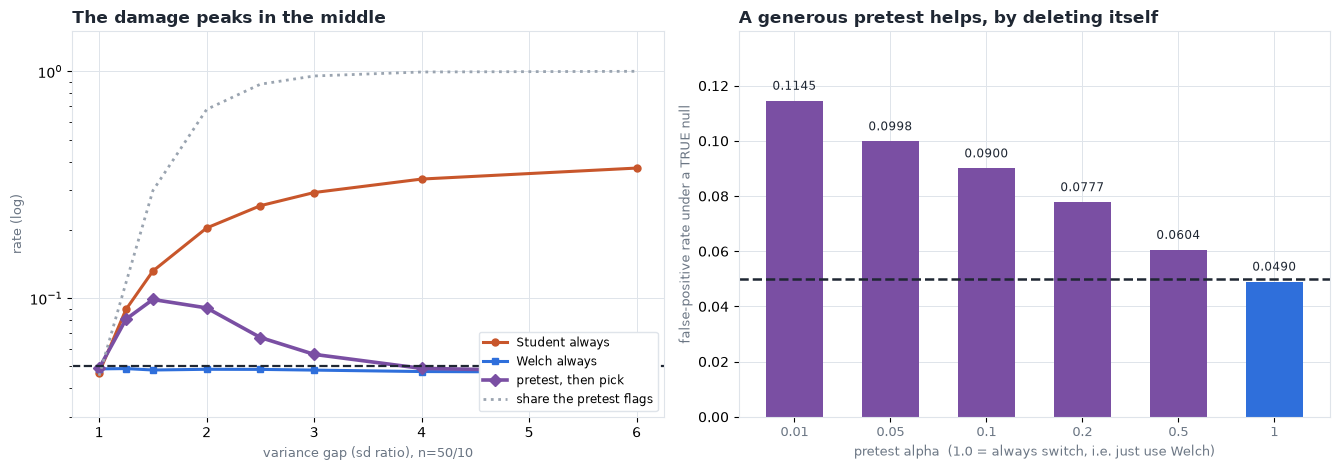

In [7]:
import matplotlib.pyplot as plt

INK, MUTED, GRID, BG = "#1f2733", "#6b7684", "#dfe4ea", "#ffffff"
STUDENT_C, WELCH_C, GATED_C, PRETEST_C = "#c8562b", "#2f6fdb", "#7a4fa3", "#9aa4b0"

ALPHAS = [0.01, 0.05, 0.10, 0.20, 0.50, 1.0]
sweep = {a: measure(50, 10, peak, reps=20_000, pretest_alpha=a, seed=41) for a in ALPHAS}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.5, 4.8), facecolor=BG)
for ax in (axL, axR):
    ax.set_facecolor(BG)
    ax.grid(True, color=GRID, lw=0.7)
    ax.set_axisbelow(True)
    for s in ax.spines.values():
        s.set_color(GRID)

axL.plot(RATIOS, [ladder[r]["student"] for r in RATIOS], "-o", color=STUDENT_C, lw=2.2, ms=5,
         label="Student always")
axL.plot(RATIOS, [ladder[r]["welch"] for r in RATIOS], "-s", color=WELCH_C, lw=2.2, ms=5,
         label="Welch always")
axL.plot(RATIOS, [ladder[r]["gated"] for r in RATIOS], "-D", color=GATED_C, lw=2.6, ms=6,
         label="pretest, then pick")
axL.plot(RATIOS, [ladder[r]["pretest_fires"] for r in RATIOS], ":", color=PRETEST_C, lw=2.0,
         label="share the pretest flags")
axL.axhline(ALPHA, color=INK, ls="--", lw=1.6)
axL.set_yscale("log")
axL.set_ylim(3e-2, 1.5)
axL.set_xlabel("variance gap (sd ratio), n=50/10", color=MUTED, fontsize=9)
axL.set_ylabel("rate (log)", color=MUTED, fontsize=9)
axL.set_title("The damage peaks in the middle", color=INK, fontsize=12, weight="bold", loc="left")
axL.legend(fontsize=8.5, framealpha=1, edgecolor=GRID, loc="lower right")

xs = np.arange(len(ALPHAS))
vals = [sweep[a]["gated"] for a in ALPHAS]
axR.bar(xs, vals, width=0.6, color=[GATED_C] * (len(ALPHAS) - 1) + [WELCH_C])
axR.axhline(ALPHA, color=INK, ls="--", lw=1.8)
for i, v in enumerate(vals):
    axR.text(i, v + 0.004, f"{v:.4f}", ha="center", fontsize=8.5, color=INK)
axR.set_xticks(xs)
axR.set_xticklabels([f"{a:g}" for a in ALPHAS], fontsize=9, color=MUTED)
axR.set_ylim(0, max(vals) * 1.22)
axR.set_xlabel("pretest alpha  (1.0 = always switch, i.e. just use Welch)", color=MUTED, fontsize=9)
axR.set_ylabel("false-positive rate under a TRUE null", color=MUTED, fontsize=9)
axR.set_title("A generous pretest helps, by deleting itself", color=INK, fontsize=12,
              weight="bold", loc="left")

fig.tight_layout()
plt.savefig("notebook_figure.png", dpi=150, facecolor=BG)
plt.show()

## 7. What the full study found

`evidence.py` runs this across 14 designs, four pretests and four population shapes at 20,000
replicates a cell, and writes `evidence.txt` and `results.json`.

| | |
|---|---|
| **The two-stage procedure never materially beat Welch** | across the grid, zero designs where it landed closer to nominal by more than the measurement error - while it broke a nominal 5% test on four of them, peaking near 2x |
| **Unconditional Welch was never broken** | not on one design in the grid, including the ones where Student's ran at 0.29 and the ones where it ran at 0.0001 |
| **The gate concentrates the danger** | on the samples the pretest cleared, Student's error is consistently *higher* than its own average - up to 1.8x - because passing the pretest and understating the pooled standard error are the same event |
| **The damage peaks at a moderate gap** | worst around a 1.5:1 sd ratio, where the pretest catches under a third of samples; at a 6:1 gap the procedure is fine because the pretest always fires and it silently becomes Welch |
| **Raising the pretest alpha does help** | monotonically, all the way to alpha = 1.0 - which is the pretest always firing, which is unconditional Welch. The fix converges on deleting the step |
| **Bartlett and the F-test read SHAPE, not variance** | on groups with *identical* variances they reject at 0.226 on skewed data and 0.004 on light-tailed data, against a nominal 0.05. And at equal n they are the same test: Spearman 1.0, identical decisions |
| **Negative result** | on a *balanced* design the whole question nearly evaporates - Student's at a 3:1 variance gap runs at 0.054. The pretest fires on 97.5% of those samples to fix a problem that is barely there |

**The replacement for the pretest is not a better pretest.** It is noticing that the branch you
would take when it fires is the one that works in every cell measured, including all the cells
where it does not fire.

## 8. Try your own

Change the design. The verdict is computed, not asserted.

In [8]:
MY_N1, MY_N2 = 40, 12
MY_SD_RATIO = 1.6          # group 2's sd, with group 1's fixed at 1.0
MY_DIST = "normal"         # normal | t5 | lognormal | uniform
MY_PRETEST = "brown-forsythe"   # levene | brown-forsythe | bartlett | f-test
MY_REPS = 20_000

r = measure(MY_N1, MY_N2, MY_SD_RATIO, MY_DIST, pretest=MY_PRETEST, reps=MY_REPS, seed=7)
ci = wilson(r["gated"], MY_REPS)
half = (wilson(ALPHA, MY_REPS)[1] - wilson(ALPHA, MY_REPS)[0]) / 2

print(f"n={MY_N1}/{MY_N2}, sd 1:{MY_SD_RATIO:g}, {MY_DIST}, {MY_PRETEST}, "
      f"{MY_REPS:,} reps, null exactly true\n")
print(f"  pretest fires on           {r['pretest_fires']:.4f} of samples")
print(f"  Student always             {r['student']:.4f}")
print(f"  Welch always               {r['welch']:.4f}")
print(f"  pretest, then pick         {r['gated']:.4f}   99% CI [{ci[0]:.4f}, {ci[1]:.4f}]")
print()

if is_broken(r["gated"], MY_REPS):
    print(f"  The two-stage procedure is NOT a {ALPHA} test here - it runs at "
          f"{r['gated'] / ALPHA:.1f}x nominal.")
elif abs(r["gated"] - ALPHA) + half < abs(r["welch"] - ALPHA):
    print("  Here the two-stage procedure genuinely beat unconditional Welch. Worth a look -")
    print("  it did not happen anywhere on the study's grid.")
else:
    print("  Not shown to be broken - but note what Welch does on the identical samples, and")
    print("  what the pretest bought you over just using it.")

if r["share_passed"] > 0.01 and r["student"] > 0:
    print(f"\n  And the mechanism: Student's runs at {r['student']:.4f} overall but "
          f"{r['student_given_pass']:.4f}")
    print(f"  on the {r['share_passed']:.0%} of samples the pretest cleared "
          f"({r['student_given_pass'] / r['student']:.2f}x).")

n=40/12, sd 1:1.6, normal, brown-forsythe, 20,000 reps, null exactly true

  pretest fires on           0.4034 of samples
  Student always             0.1241
  Welch always               0.0520
  pretest, then pick         0.0886   99% CI [0.0836, 0.0939]

  The two-stage procedure is NOT a 0.05 test here - it runs at 1.8x nominal.

  And the mechanism: Student's runs at 0.1241 overall but 0.1326
  on the 60% of samples the pretest cleared (1.07x).


---

**Built by Phoebe Fu** - one mini product a day. [Repo](https://github.com/phoebefu6/phoebe-the-builder) ·
[This build](data-science-cookbook/assumption-pretest-cost)

The same study runs as a Streamlit app where you can drag the design around instead of editing
constants:

```bash
pip install -r requirements.txt
streamlit run app.py
```

`evidence.py` regenerates every number quoted here into `evidence.txt` and `results.json`, and
`pytest` asserts the findings - including that the "did the two-stage procedure beat Welch"
predicate is capable of returning True - so a library change that breaks one of them fails the
suite.

Sibling build: [`normality-test-trap`](../normality-test-trap) does the same job for the
*normality* pretest, and scored that gate at sensitivity 0.81 / specificity 0.38.